In [275]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV , train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , recall_score , f1_score 

# Load the Data

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# Null Values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [12]:
obj_col=df.select_dtypes(include=["object"]).columns 

In [13]:
num_col=df.select_dtypes(include=["float64"]).columns

In [14]:
obj_col

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [15]:
num_col

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [19]:
obj_imp=SimpleImputer(strategy="most_frequent")
df[obj_col]=obj_imp.fit_transform(df[obj_col])

In [21]:
num_imp=SimpleImputer(strategy="mean")
df[num_col]=num_imp.fit_transform(df[num_col])

In [25]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

# EDA 

In [26]:
df.sample(2)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
774,775.0,10852.571579,6807.0,Salaried,50.0,Married,3.0,786.0,1.0,0.40,5154.0,6766.0,26685.0,84.0,Education,Rural,Graduate,Female,MNC,No
800,801.0,13954.000000,7421.0,Salaried,39.0,Single,2.0,763.0,0.0,0.23,9990.0,35224.0,20726.0,84.0,Car,Rural,Graduate,Male,Business,No


Text(0.5, 1.0, 'LOAN APPROVAL RATIO')

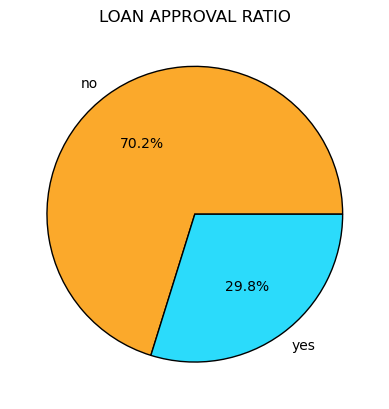

In [72]:
# Let's grab some Insights about the data 
out_count=df["Loan_Approved"].value_counts()
plt.pie(out_count,labels=["no","yes"],
        autopct="%1.1f%%",
        colors=["#fba92b","#2bdbfb"],
        wedgeprops={"edgecolor":"black"})
plt.title("LOAN APPROVAL RATIO")

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

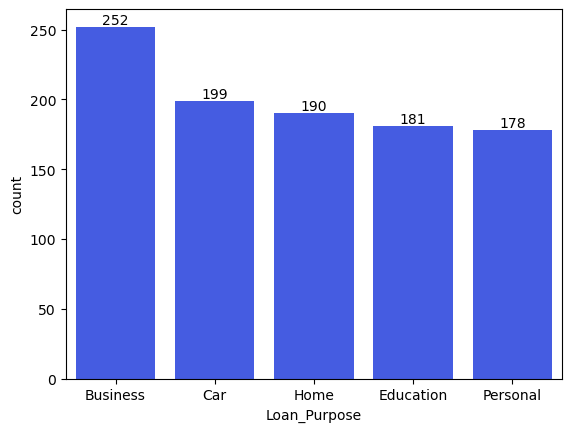

In [73]:
# Analyzes the cateogries
class_count=df["Loan_Purpose"].value_counts()
ax = sns.barplot(class_count,color="#2b4afb")
ax.bar_label(ax.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

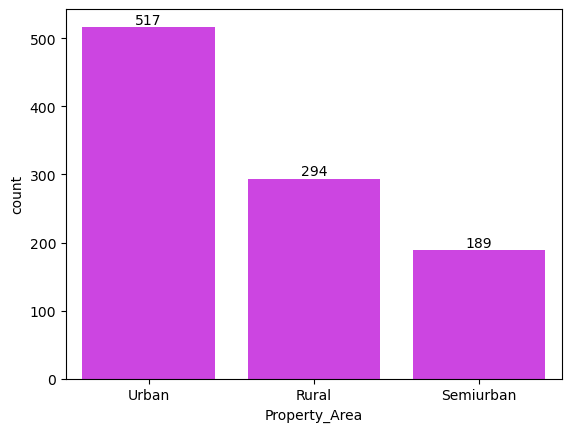

In [76]:
class_count=df["Property_Area"].value_counts()
ax = sns.barplot(class_count ,color="#df2bfb")
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

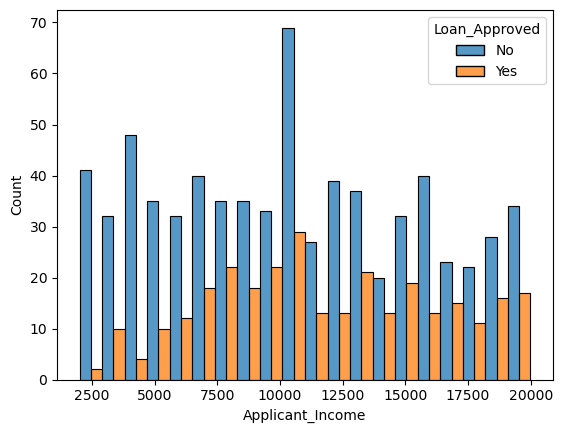

In [97]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [92]:
num_col

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

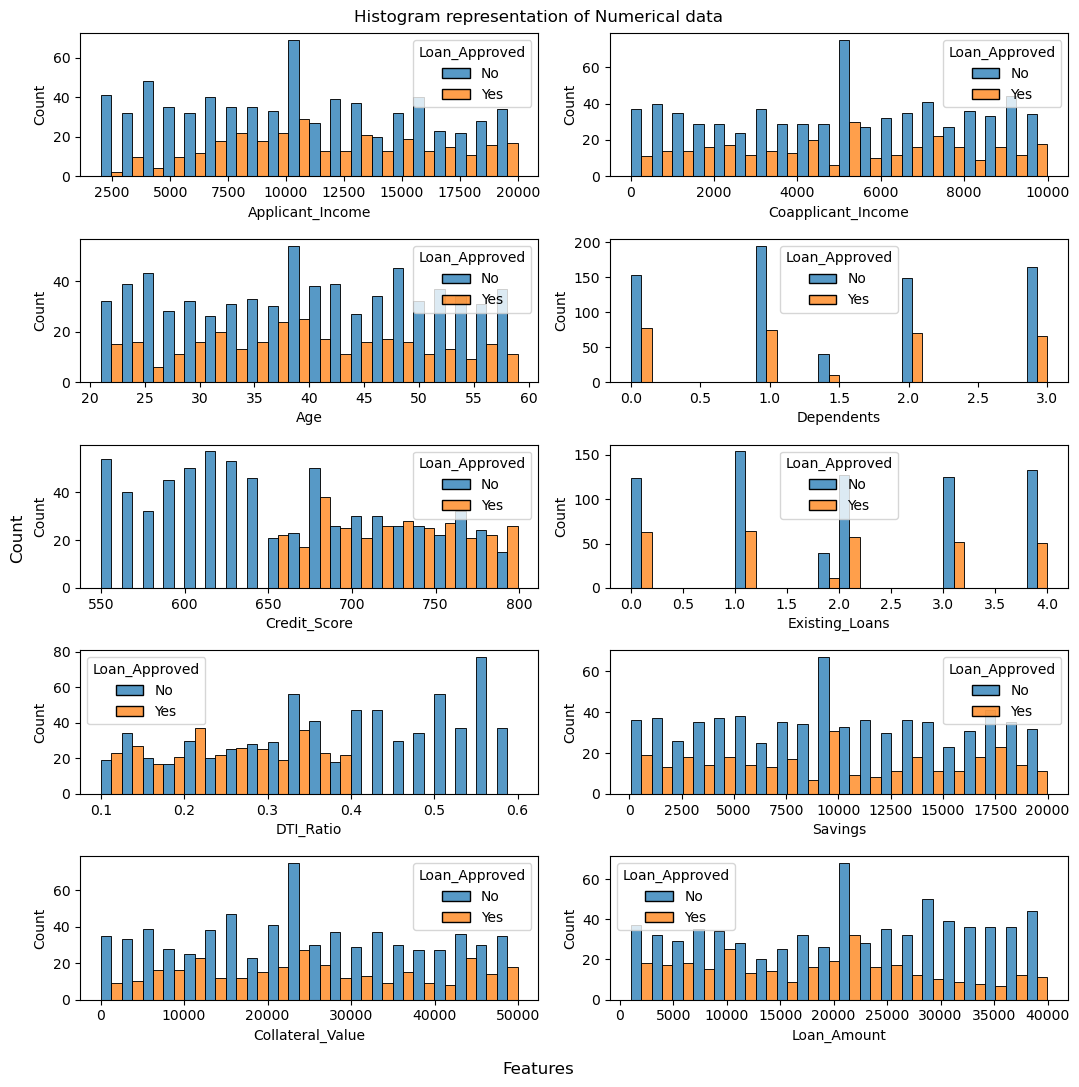

In [153]:
col=1
fig , axes = plt.subplots(5,2 ,figsize=(11,11))
for i in range(0,5):          # 0,1 ,0,2, 1,1,1,2, 2,1,2,1
    for j in range(0,2):
        sns.histplot(
            ax=axes[i,j],
            data=df,
            x=num_col[col],
            bins=20,
            hue="Loan_Approved",
            multiple="dodge"
        )
        col+=1
fig.suptitle("Histogram representation of Numerical data")
fig.supxlabel("Features")
fig.supylabel("Count")
fig.tight_layout()

# OUTLIERS DETECTION WITH BOX PLOT

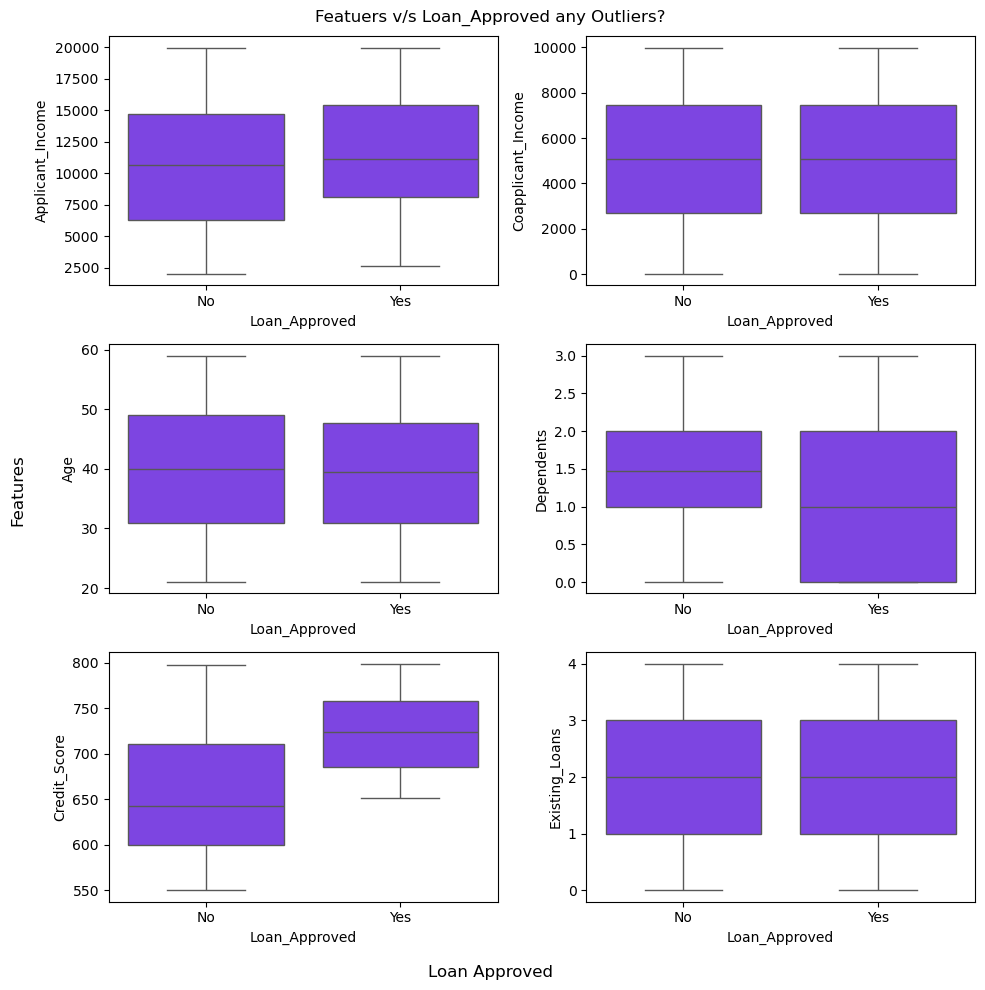

In [138]:
col=1
fig , axes = plt.subplots(3,2 ,figsize=(10,10))
for i in range(0,3):          # 0,1 ,0,2, 1,1,1,2, 2,1,2,1
    for j in range(0,2):
        sns.boxplot(
            ax=axes[i,j],
            data=df,
            y=num_col[col],
            x="Loan_Approved",
            color="#752bfb",
        )
        col+=1
fig.suptitle("Featuers v/s Loan_Approved any Outliers?")
fig.supxlabel("Loan Approved")
fig.supylabel("Features")
fig.tight_layout()

In [139]:
obj_col

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

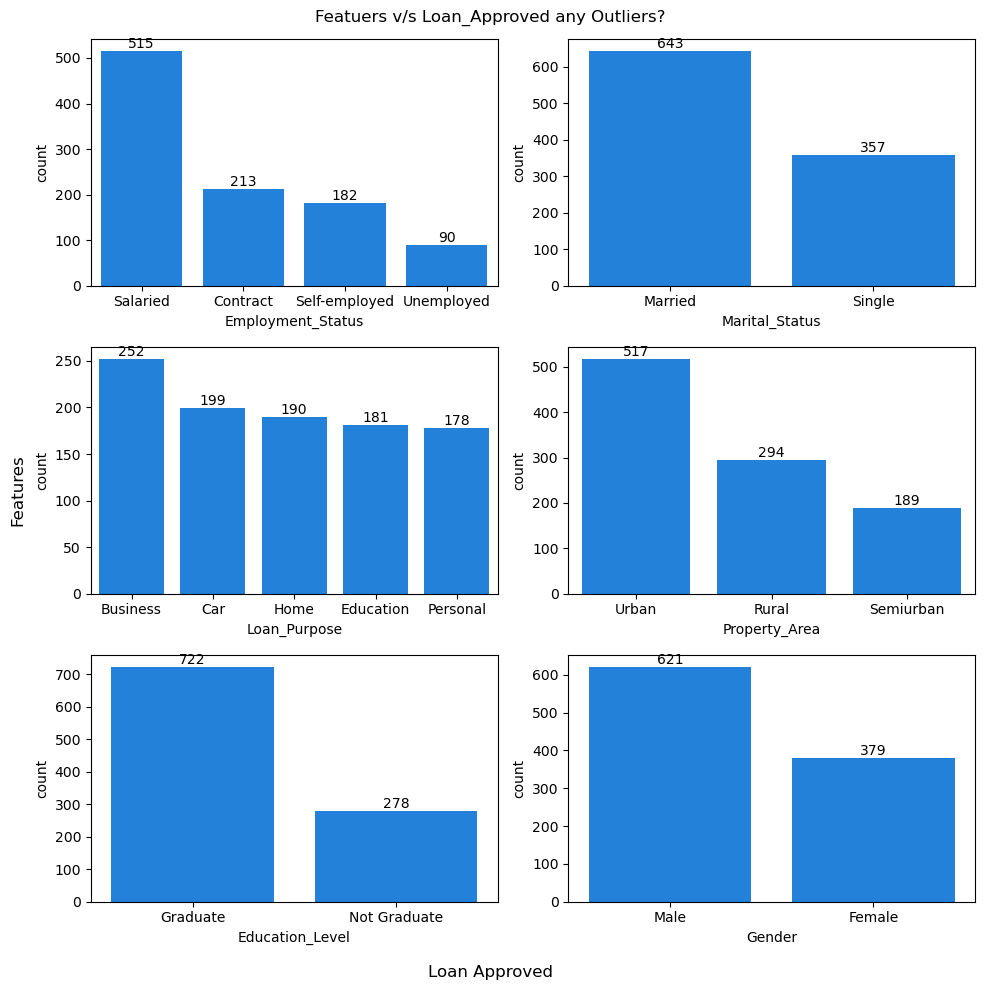

In [155]:
col=0
fig , axes = plt.subplots(3,2 ,figsize=(10,10))
for i in range(0,3):          # 0,1 ,0,2, 1,1,1,2, 2,1,2,1
    for j in range(0,2):
        class_count=df[obj_col[col]].value_counts()
        plot=sns.barplot(
            ax=axes[i,j],
            data=class_count,
            color="#0482f8",     
            )
        plot.bar_label(plot.containers[0])
        col+=1
fig.suptitle("Featuers v/s Loan_Approved any Outliers?")
fig.supxlabel("Loan Approved")
fig.supylabel("Features")
fig.tight_layout()

# Label Encoding

In [156]:
df.sample(1)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
17,18.0,8420.0,2051.0,Salaried,34.0,Married,1.0,562.0,4.0,0.4,12878.0,7351.0,19170.0,48.0,Home,Urban,Graduate,Male,Private,No


In [170]:
le=LabelEncoder()
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df["Education_Level"]=le.fit_transform(df["Education_Level"])

In [173]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]     

df2=df[cols]

In [178]:
ohe=OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)

values=ohe.fit_transform(df2[cols])  # form of array --> DataFrame

In [183]:
df2=pd.DataFrame(values,columns=ohe.get_feature_names_out(cols))

In [217]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [203]:
# concatenate
df=pd.concat([df.drop(columns=cols) , df2 ],axis=1)

In [213]:
X=df.drop(columns=["Applicant_ID","Loan_Approved"])
y=df["Loan_Approved"]

# Train Test Split

In [218]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,y,random_state=42,test_size=0.3
)

# Scaling Data

In [220]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [274]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(X_train_scaled , Y_train)
Y_pred = model.predict(X_test_scaled)
Y_tpred = model.predict(X_train_scaled)

lr_acc_test = accuracy_score(Y_test,Y_pred)
lr_acc_train = accuracy_score(Y_train,Y_tpred)

lr_prec_test =precision_score(Y_test,Y_pred)
lr_prec_train = precision_score(Y_train,Y_tpred)

lr_recall_test = recall_score(Y_test,Y_pred)
lr_recall_train = recall_score(Y_train,Y_tpred)

lr_f1_test = f1_score(Y_test,Y_pred)
lr_f1_train = f1_score(Y_train,Y_tpred)

print(f'accuracy :\n train | { lr_acc_train *100} % \n test | {lr_acc_test *100} % \n')
print(f'precision :\n train | { lr_prec_train *100} % \n test | {lr_prec_test *100} %\n')
print(f'recall :\n train | { lr_recall_train *100} % \n test | {lr_recall_test *100} %\n')
print(f'f1 :\n train | { lr_f1_train *100} % \n test | {lr_f1_test *100} %')



accuracy :
 train | 86.71428571428571 % 
 test | 86.66666666666667 % 

precision :
 train | 80.57142857142857 % 
 test | 83.72093023255815 %

recall :
 train | 70.5 % 
 test | 73.46938775510205 %

f1 :
 train | 75.2 % 
 test | 78.26086956521739 %


# DecisionTree

In [276]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("dt",DecisionTreeClassifier())
])
param={
    "dt__max_depth":[3,4,5,6,7],
    "dt__min_samples_split":[2,3,4],
    "dt__min_samples_leaf":[2,3,4]
}
model=GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5,
    scoring="precision"
)

model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

dt_acc_test = accuracy_score(Y_test,Y_pred)
dt_acc_train = accuracy_score(Y_train,Y_tpred)

dt_prec_test =precision_score(Y_test,Y_pred)
dt_prec_train = precision_score(Y_train,Y_tpred)

dt_recall_test = recall_score(Y_test,Y_pred)
dt_recall_train = recall_score(Y_train,Y_tpred)

dt_f1_test = f1_score(Y_test,Y_pred)
dt_f1_train = f1_score(Y_train,Y_tpred)

print(f'accuracy :\n train | {dt_acc_train *100} % \n test | {dt_acc_test *100} % \n')
print(f'precision :\n train | { dt_prec_train *100} % \n test | {dt_prec_test *100} %\n')
print(f'recall :\n train | { dt_recall_train *100} % \n test | {dt_recall_test *100} %\n')
print(f'f1 :\n train | { dt_f1_train *100} % \n test | {dt_f1_test *100} %\n')

print(model.best_params_)

accuracy :
 train | 96.28571428571429 % 
 test | 89.0 % 

precision :
 train | 92.64705882352942 % 
 test | 83.50515463917526 %

recall :
 train | 94.5 % 
 test | 82.6530612244898 %

f1 :
 train | 93.56435643564357 % 
 test | 83.07692307692308 %

{'dt__max_depth': 7, 'dt__min_samples_leaf': 3, 'dt__min_samples_split': 3}


# RandomForest

In [278]:
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("rf",RandomForestClassifier(max_depth=7,min_samples_split=2,min_samples_leaf=4))
])
param={
    "rf__n_estimators":[200,300]
}
model=GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5,
    scoring="precision"
)

model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

rf_acc_test = accuracy_score(Y_test,Y_pred)
rf_acc_train = accuracy_score(Y_train,Y_tpred)

rf_prec_test =precision_score(Y_test,Y_pred)
rf_prec_train = precision_score(Y_train,Y_tpred)

rf_recall_test = recall_score(Y_test,Y_pred)
rf_recall_train = recall_score(Y_train,Y_tpred)

rf_f1_test = f1_score(Y_test,Y_pred)
rf_f1_train = f1_score(Y_train,Y_tpred)

print(f'accuracy :\n train | { rf_acc_train *100} % \n test | {rf_acc_test *100} % \n')
print(f'precision :\n train | { rf_prec_train *100} % \n test | {rf_prec_test *100} %\n')
print(f'recall :\n train | { rf_recall_train *100} % \n test | {rf_recall_test *100} %\n')
print(f'f1 :\n train | { rf_f1_train *100} % \n test | {rf_f1_test *100} %\n')

print(model.best_params_)

accuracy :
 train | 98.42857142857143 % 
 test | 90.33333333333333 % 

precision :
 train | 95.21531100478468 % 
 test | 87.09677419354838 %

recall :
 train | 99.5 % 
 test | 82.6530612244898 %

f1 :
 train | 97.31051344743277 % 
 test | 84.81675392670157 %

{'rf__n_estimators': 300}


# Comparisonal Model Graph 

In [339]:
train_acc=[lr_acc_train,dt_acc_train,rf_acc_train]
test_acc=[lr_acc_test,dt_acc_test,rf_acc_test]

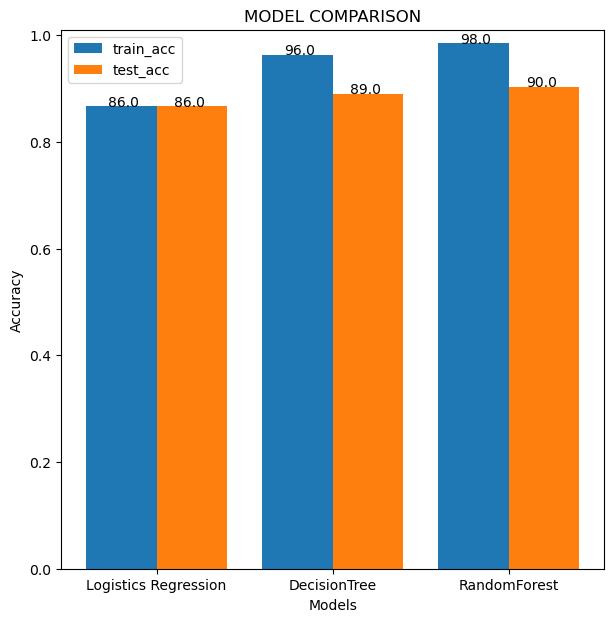

In [340]:
X=np.array([1,2,3])
name=["Logistics Regression","DecisionTree","RandomForest"]
train_acc=[lr_acc_train,dt_acc_train,rf_acc_train]
test_acc=[lr_acc_test,dt_acc_test,rf_acc_test]
width=0.40
plt.figure(figsize=(7,7))
plt.bar( X- width/2, train_acc,width,label="train_acc")
plt.bar( X+ width/2, test_acc,width,label="test_acc")
plt.title("MODEL COMPARISON")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1+0.01)
plt.xticks(X,name)
plt.legend()

for i in range(len(name)):
    plt.text(X[i]-0.1,train_acc[i],str(train_acc[i]*100//1), ha="right")
    plt.text(X[i]+0.1,test_acc[i],str(test_acc[i]*100//1), ha="left")